## 1. Environment Setting

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import datetime

# Plotting style
plt.style.use("seaborn-v0_8-muted")
plt.rcParams["figure.figsize"] = (12, 6)

## 2. Data Acquisition

In [ ]:
tickers = ['AAPL','MSFT','AMZN','GOOGL','META','TSLA','BKR','JPM','JNJ','V',
           'WMT','PG','MA','UNH','BAC','HD','NVDA','ADBE','PYPL','DIS']
benchmark = 'SPY'

start_date = "2015-01-01"
end_date = "2026-01-01"

In [ ]:
data = yf.download(tickers,
                   start=start_date, end=end_date,
                   progress = False, auto_adjust=False)['Adj Close']
benchmark = yf.download(benchmark, start=start_date, end=end_date,
                   progress = False, auto_adjust=False)['Adj Close']
print(data.shape)
data.tail()

(2766, 20)


Ticker,AAPL,ADBE,AMZN,BAC,BKR,DIS,GOOGL,HD,JNJ,JPM,MA,META,MSFT,NVDA,PG,PYPL,TSLA,UNH,V,WMT
Date,,,,,,,,,,,,,,,,,,,,
2025-12-24,273.809998,352.980011,232.380005,56.250000,45.299999,114.480003,314.089996,347.339996,207.779999,327.691864,578.580933,667.549988,488.019989,188.610001,143.471359,60.040001,485.399994,327.579987,355.140015,111.610001
2025-12-26,273.399994,353.799988,232.520004,56.169998,45.250000,113.559998,313.510010,349.779999,207.630005,326.437531,578.730652,663.289978,487.709991,190.529999,143.719589,59.970001,475.190002,331.829987,355.000000,111.739998
2025-12-29,273.760010,353.160004,232.070007,55.349998,45.380001,114.190002,313.559998,347.450012,207.559998,322.296204,577.033264,658.690002,487.100006,188.220001,143.550797,59.490002,459.640015,328.940002,354.609985,112.529999
2025-12-30,273.079987,352.510010,232.529999,55.279999,46.090000,114.790001,313.850006,346.350006,206.910004,321.967712,576.553955,665.950012,487.480011,187.539993,143.034454,59.099998,454.429993,332.160004,353.619995,111.919998
2025-12-31,271.859985,349.989990,230.820007,55.000000,45.540001,113.769997,313.000000,344.100006,206.949997,320.773071,570.023804,660.090027,483.619995,186.500000,142.299667,58.380001,449.720001,330.109985,350.709991,111.410004


In [ ]:
monthly_prices = data.resample('ME').last()
print(monthly_prices.shape)
monthly_prices

(132, 20)


Ticker,AAPL,ADBE,AMZN,BAC,BKR,DIS,GOOGL,HD,JNJ,JPM,MA,META,MSFT,NVDA,PG,PYPL,TSLA,UNH,V,WMT
Date,,,,,,,,,,,,,,,,,,,,
2015-01-31,25.973398,70.129997,17.726500,12.021520,30.925636,82.825439,26.675945,80.666695,73.730652,40.474888,76.725838,75.383423,34.437172,0.460696,61.995808,NaN,13.573333,89.065788,59.000942,22.970556
2015-02-28,28.590908,79.099998,19.007999,12.545231,33.336117,94.772141,27.920540,88.646858,76.003990,45.610531,84.302101,78.422203,37.643955,0.531359,62.613632,NaN,13.556000,95.252213,62.910973,22.686737
2015-03-31,27.693962,73.940002,18.605000,12.250149,33.999207,95.509674,27.527014,88.217819,74.587830,45.089516,80.803932,81.649651,34.905449,0.504141,60.267342,NaN,12.584667,99.490273,60.668713,22.366161
2015-04-30,27.854210,76.059998,21.089001,12.679978,36.608772,98.997185,27.232737,83.069626,73.549820,47.397198,84.531792,78.223579,41.756042,0.534731,58.950451,NaN,15.070000,93.695305,61.262337,21.224058
2015-05-31,29.117094,79.089996,21.461500,13.133685,34.469788,100.499619,27.061531,86.517265,74.788223,49.285286,86.452751,78.640671,40.489403,0.535512,58.120079,NaN,16.719999,101.105133,63.813171,20.323624
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-31,231.915176,356.700012,229.000000,50.198471,45.185322,117.584435,212.580704,401.876038,176.052200,298.614685,593.613464,737.600159,505.743439,174.160477,154.850006,70.028114,333.869995,305.870789,351.084595,96.782715
2025-09-30,254.383408,352.750000,219.570007,51.323288,48.489624,113.730515,242.941101,402.586151,184.250153,312.494293,567.208008,733.781555,516.982422,186.569611,151.507294,66.905327,444.720001,342.993866,340.705139,102.850342
2025-10-31,270.108154,340.309998,244.220001,53.173672,48.181087,111.863152,281.006195,377.150665,187.678391,309.722900,551.162109,647.821655,516.842651,202.478729,149.309891,69.110229,456.559998,339.278870,340.066406,100.974167


To calculate the daily percentage change of each asset:$$r_t = \frac{P_t - P_{t-1}}{P_{t-1}}$$where $P_t$ is the adjusted closing price at time $t$.

In [ ]:
daily_returns = data.pct_change().dropna()
print(daily_returns.shape)
daily_returns.head()

(2639, 20)


Ticker,AAPL,ADBE,AMZN,BAC,BKR,DIS,GOOGL,HD,JNJ,JPM,MA,META,MSFT,NVDA,PG,PYPL,TSLA,UNH,V,WMT
Date,,,,,,,,,,,,,,,,,,,,
2015-07-07,-0.002460,0.001118,0.001560,-0.014758,0.023271,0.012100,0.008083,0.009702,0.007332,-0.007872,-0.004981,-0.003769,-0.002027,-0.018840,0.020862,-0.002452,-0.042328,-0.011952,-0.005138,0.017372
2015-07-08,-0.024823,-0.007445,-0.016074,-0.026363,-0.015491,-0.016311,-0.015145,-0.012456,-0.011625,-0.020509,-0.014911,-0.018001,-0.001355,-0.007074,-0.008933,-0.052430,-0.048231,-0.015907,-0.015346,-0.009893
2015-07-09,-0.020397,0.006001,0.010915,0.014153,0.006863,0.003559,0.005446,0.003424,0.006444,0.010393,0.005947,0.002685,0.006329,-0.012214,-0.004075,-0.005764,0.011610,0.004715,0.004795,-0.003832
2015-07-10,0.026734,0.001491,0.020995,0.013350,-0.007315,0.007267,0.021041,0.015443,0.011484,0.014219,0.016982,0.024103,0.002022,0.017517,0.003595,0.005507,0.004769,0.023546,0.020433,0.004672
2015-07-13,0.019306,0.010547,0.027192,0.019162,0.009881,0.013827,0.028088,0.015915,0.007435,0.015511,0.009301,0.024446,0.020847,0.006582,0.011859,0.060248,0.011615,0.002456,0.016077,0.010394


## 3. Monthly Rebalancing Logic

In [ ]:
portfolio_returns_list = []

# We start from month 12 (to have 1 year of data for the first momentum calculation)
for i in range(12, len(monthly_prices) - 1):

    # A. Get Dates
    rebalance_date = monthly_prices.index[i]   # Today: When we decide what to buy
    next_month_end = monthly_prices.index[i+1] # Future: The period we will hold the stocks

    # B. Momentum Selection (Rank stocks by 12-month performance)
    momentum_scores = (monthly_prices.iloc[i] / monthly_prices.iloc[i-12]) - 1
    # Sort and pick top 10 (filter out negative momentum)
    positive_mom = momentum_scores[momentum_scores > 0]
    top10_tickers = positive_mom.sort_values(ascending=False).head(10)

    if not top10_tickers.empty:
        # C. Risk-Adjusted Weighting
        # Get the daily returns of the PAST year for these 10 stocks only
        past_year_returns = daily_returns.loc[:rebalance_date].tail(252)[top10_tickers.index]

        # Calculate Volatility (Standard Deviation)
        vol = past_year_returns.std() * np.sqrt(252)

        # Formula: Weight = Momentum / Volatility
        raw_weights = top10_tickers / vol
        final_weights = raw_weights / raw_weights.sum() # Ensure total = 100%

        # D. Calculate Next Month's Return (Out-of-Sample)
        # We apply the weights decided "today" to the returns of "tomorrow"
        next_month_actual_rets = daily_returns.loc[rebalance_date:next_month_end].iloc[1:][top10_tickers.index]

        # Multiply weights by actual performance
        daily_portfolio_ret = (next_month_actual_rets * final_weights).sum(axis=1)
        portfolio_returns_list.append(daily_portfolio_ret)

# Combine all monthly segments into one continuous series
raw_strategy_returns = pd.concat(portfolio_returns_list)


In [ ]:
rebalance_date

Timestamp('2025-11-30 00:00:00')

In [ ]:
next_month_end

Timestamp('2025-12-31 00:00:00')

In [ ]:
# momentum_scores = (monthly_prices.iloc[-1] / monthly_prices.iloc[-1-12]) - 1
print(top10_tickers.sort_values(ascending=False))


Ticker
GOOGL    0.903475
JNJ      0.375743
NVDA     0.280656
JPM      0.280264
TSLA     0.246292
WMT      0.206352
AAPL     0.180260
MSFT     0.170452
BKR      0.166624
BAC      0.155811
dtype: float64


In [ ]:
momentum_weights = top10_tickers/top10_tickers.sum()
print(momentum_weights.sort_values(ascending=False))

Ticker
GOOGL    0.304618
JNJ      0.126687
NVDA     0.094627
JPM      0.094495
TSLA     0.083040
WMT      0.069574
AAPL     0.060777
MSFT     0.057470
BKR      0.056179
BAC      0.052534
dtype: float64


In [ ]:
print(vol.sort_values(ascending=False))

Ticker
TSLA     0.652284
NVDA     0.496417
BKR      0.354336
GOOGL    0.331900
AAPL     0.325502
BAC      0.268845
WMT      0.251644
MSFT     0.244070
JPM      0.242495
JNJ      0.193228
dtype: float64


In [ ]:
print(final_weights.sort_values(ascending=False))

Ticker
GOOGL    0.275314
JNJ      0.196671
JPM      0.116892
WMT      0.082936
MSFT     0.070633
BAC      0.058616
NVDA     0.057180
AAPL     0.056010
BKR      0.047560
TSLA     0.038188
dtype: float64


In [ ]:
print(raw_weights.sort_values(ascending=False))

Ticker
GOOGL    2.722133
JNJ      1.944555
JPM      1.155752
WMT      0.820014
MSFT     0.698372
BAC      0.579556
NVDA     0.565364
AAPL     0.553792
BKR      0.470244
TSLA     0.377583
dtype: float64


In [ ]:
next_month_actual_rets

Ticker,GOOGL,JNJ,NVDA,JPM,TSLA,WMT,AAPL,MSFT,BKR,BAC
Date,,,,,,,,,,
2025-12-02,0.002922,0.000390,0.008559,-0.003367,-0.002092,0.007890,0.010915,0.006698,-0.013557,-0.000939
2025-12-03,0.012096,-0.000438,-0.010305,0.013804,0.040770,0.017792,-0.007128,-0.025041,0.020412,0.016921
2025-12-04,-0.006289,-0.013880,0.021161,0.012719,0.017437,0.003758,-0.012141,0.006510,0.002377,0.001294
2025-12-05,0.011492,-0.002716,-0.005290,-0.003353,0.001034,0.002351,-0.006840,0.004825,-0.027860,0.001299
2025-12-08,-0.022862,-0.001535,0.017214,0.000540,-0.033890,-0.013465,-0.003192,0.016268,-0.036789,-0.000927
2025-12-09,0.010710,-0.008233,-0.003126,-0.046636,0.012717,0.013209,-0.002555,0.002037,0.006330,-0.006679
2025-12-10,0.009871,0.032907,-0.006433,0.031946,0.014107,-0.016339,0.005772,-0.027357,0.007339,0.010086
2025-12-11,-0.024297,0.016801,-0.015508,0.023443,-0.010101,0.020675,-0.002690,0.010260,-0.012073,0.008876
2025-12-12,-0.010050,0.007476,-0.032665,0.003592,0.027009,0.012274,0.000899,-0.010218,-0.012642,0.010630


## 4. Trend Filtering (EMA 9/25)


In [ ]:
# 1. Create the Equity Curve (Growth of $1)
equity_curve = (1 + raw_strategy_returns).cumprod()

# 2. Calculate Exponential Moving Averages
ema9 = equity_curve.ewm(span=9, adjust=False).mean()
ema25 = equity_curve.ewm(span=25, adjust=False).mean()

# 3. Generate Signal: 1 (In Market) or 0 (In Cash)
# We shift(1) to ensure we don't use today's price to predict today's trade (Avoid Bias)
signal = (ema9 > ema25).astype(int).shift(1).fillna(0)

# 4. Final Strategy Returns (Raw Returns * Signal)
final_strategy_returns = raw_strategy_returns * signal


## 5. Performance Evaluation

In [ ]:
spy_daily_returns = benchmark.pct_change().dropna()
spy_ret_df = spy_daily_returns.loc[raw_strategy_returns.index[0]:raw_strategy_returns.index[-1]]

In [ ]:
# 1. Performance Calculation Function
def calculate_metrics(returns):
    # Cumulative Returns
    cum_ret = (1 + returns).cumprod()
    total_return = cum_ret.iloc[-1] - 1

    # Annualized Return (CAGR)
    days = len(returns)
    cagr = (1 + total_return)**(252/days) - 1

    # Volatility & Sharpe Ratio (Risk-Free Rate assumed at 0% for simplicity)
    vol = returns.std() * np.sqrt(252)
    sharpe = cagr / vol

    # Maximum Drawdown
    rolling_max = cum_ret.cummax()
    drawdown = (cum_ret - rolling_max) / rolling_max
    max_dd = drawdown.min()

    return total_return, cagr, vol, sharpe, max_dd, drawdown

# 2. Execute Calculation
strat_metrics = calculate_metrics(final_strategy_returns)
spy_metrics = calculate_metrics(spy_ret_df)

# 3. Print Comparison Table
metrics_df = pd.DataFrame({
    "Metric": ["Total Return", "Annualized (CAGR)", "Volatility", "Sharpe Ratio", "Max Drawdown"],
    "Strategy": [f"{strat_metrics[0]:.2%}", f"{strat_metrics[1]:.2%}", f"{strat_metrics[2]:.2%}", f"{strat_metrics[3]:.2f}", f"{strat_metrics[4]:.2%}"],
    "S&P 500 (SPY)": [f"{spy_metrics[0].item():.2%}", f"{spy_metrics[1].item():.2%}", f"{spy_metrics[2].item():.2%}", f"{spy_metrics[3].item():.2f}", f"{spy_metrics[4].item():.2%}"]
})

print("--- Performance Summary (2015 - 2025) ---")
print(metrics_df.to_string(index=False))

--- Performance Summary (2015 - 2025) ---
           Metric Strategy S&P 500 (SPY)
     Total Return  711.90%       315.49%
Annualized (CAGR)   23.93%        15.48%
       Volatility   18.15%        17.96%
     Sharpe Ratio     1.32          0.86
     Max Drawdown  -22.21%       -33.72%


## 6. Visualize

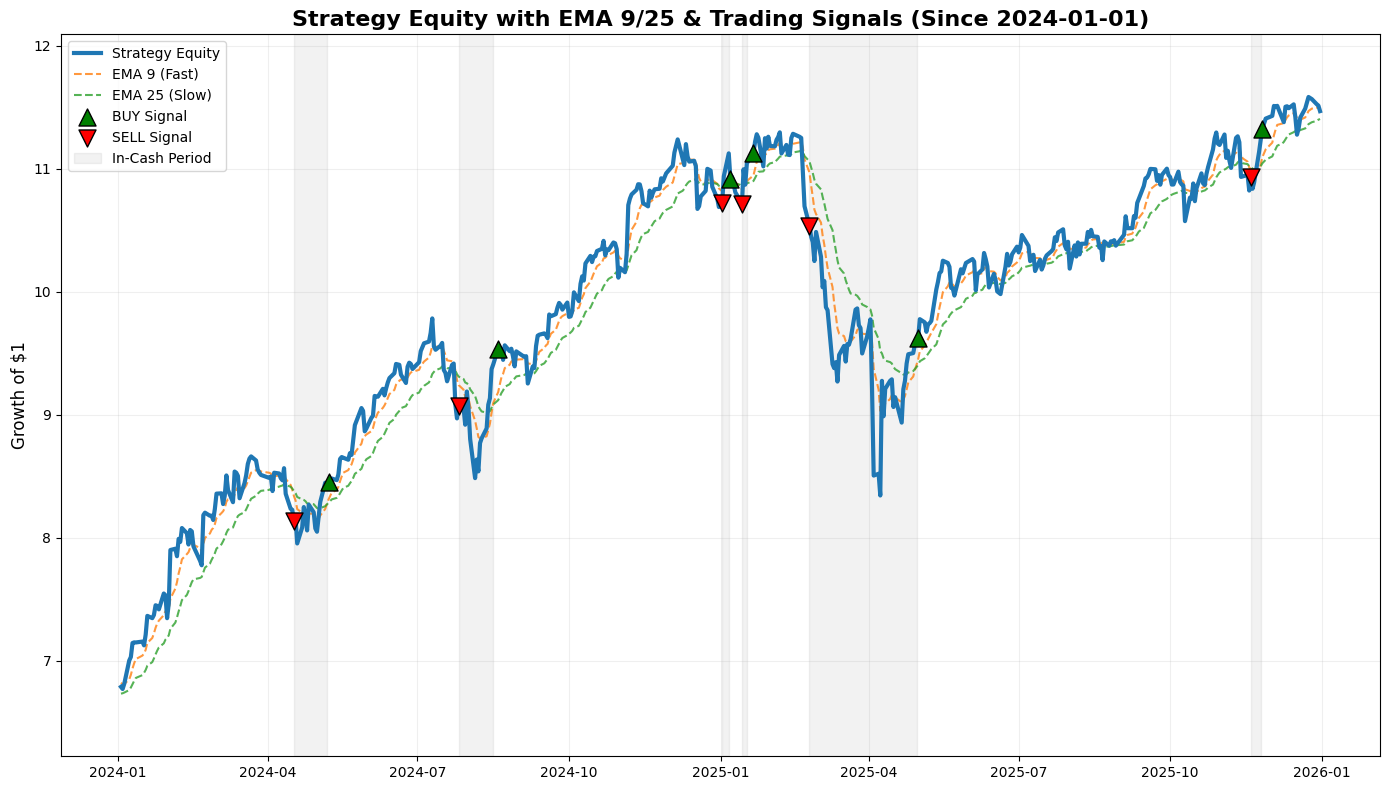

In [ ]:
# 1. Configure the Start Date for the plot
plot_start_date = '2024-01-01'

# 2. Filter Data (Equity, EMAs, and Signal) from 2022 onwards
equity_series = (1 + raw_strategy_returns).cumprod()
filtered_equity = equity_series[equity_series.index >= plot_start_date]
filtered_ema9 = ema9[ema9.index >= plot_start_date]
filtered_ema25 = ema25[ema25.index >= plot_start_date]
filtered_signal = signal[signal.index >= plot_start_date]

# 3. Filter Buy and Sell signals for this specific period
buys = signal[(signal == 1) & (signal.shift(1) == 0)].index
sells = signal[(signal == 0) & (signal.shift(1) == 1)].index
buys_filtered = [d for d in buys if d >= pd.to_datetime(plot_start_date)]
sells_filtered = [d for d in sells if d >= pd.to_datetime(plot_start_date)]

# 4. Visualization
plt.figure(figsize=(14, 8))

# Plot Strategy Equity Curve
plt.plot(filtered_equity, label='Strategy Equity', color='#1f77b4', lw=3, zorder=3)

# Plot EMAs (The logic behind the signals)
plt.plot(filtered_ema9, label='EMA 9 (Fast)', color='#ff7f0e', lw=1.5, linestyle='--', alpha=0.8, zorder=2)
plt.plot(filtered_ema25, label='EMA 25 (Slow)', color='#2ca02c', lw=1.5, linestyle='--', alpha=0.8, zorder=2)

# Plot BUY Signals (Green Upward Triangle)
if buys_filtered:
    plt.scatter(buys_filtered, filtered_equity.loc[buys_filtered],
                marker='^', color='green', s=150, label='BUY Signal', zorder=5, edgecolors='black')

# Plot SELL Signals (Red Downward Triangle)
if sells_filtered:
    plt.scatter(sells_filtered, filtered_equity.loc[sells_filtered],
                marker='v', color='red', s=150, label='SELL Signal', zorder=5, edgecolors='black')

# Highlight "In-Cash" Periods (When Signal = 0)
cash_mask = (filtered_signal == 0)
plt.fill_between(filtered_signal.index, 0, 1, where=cash_mask, color='gray', alpha=0.1,
                 transform=plt.gca().get_xaxis_transform(), label='In-Cash Period')

# Chart Formatting
plt.title(f'Strategy Equity with EMA 9/25 & Trading Signals (Since {plot_start_date})', fontsize=16, fontweight='bold')
plt.ylabel('Growth of $1', fontsize=12)
plt.grid(True, alpha=0.2)
plt.legend(loc='upper left', frameon=True, fontsize=10)
plt.tight_layout()

plt.show()

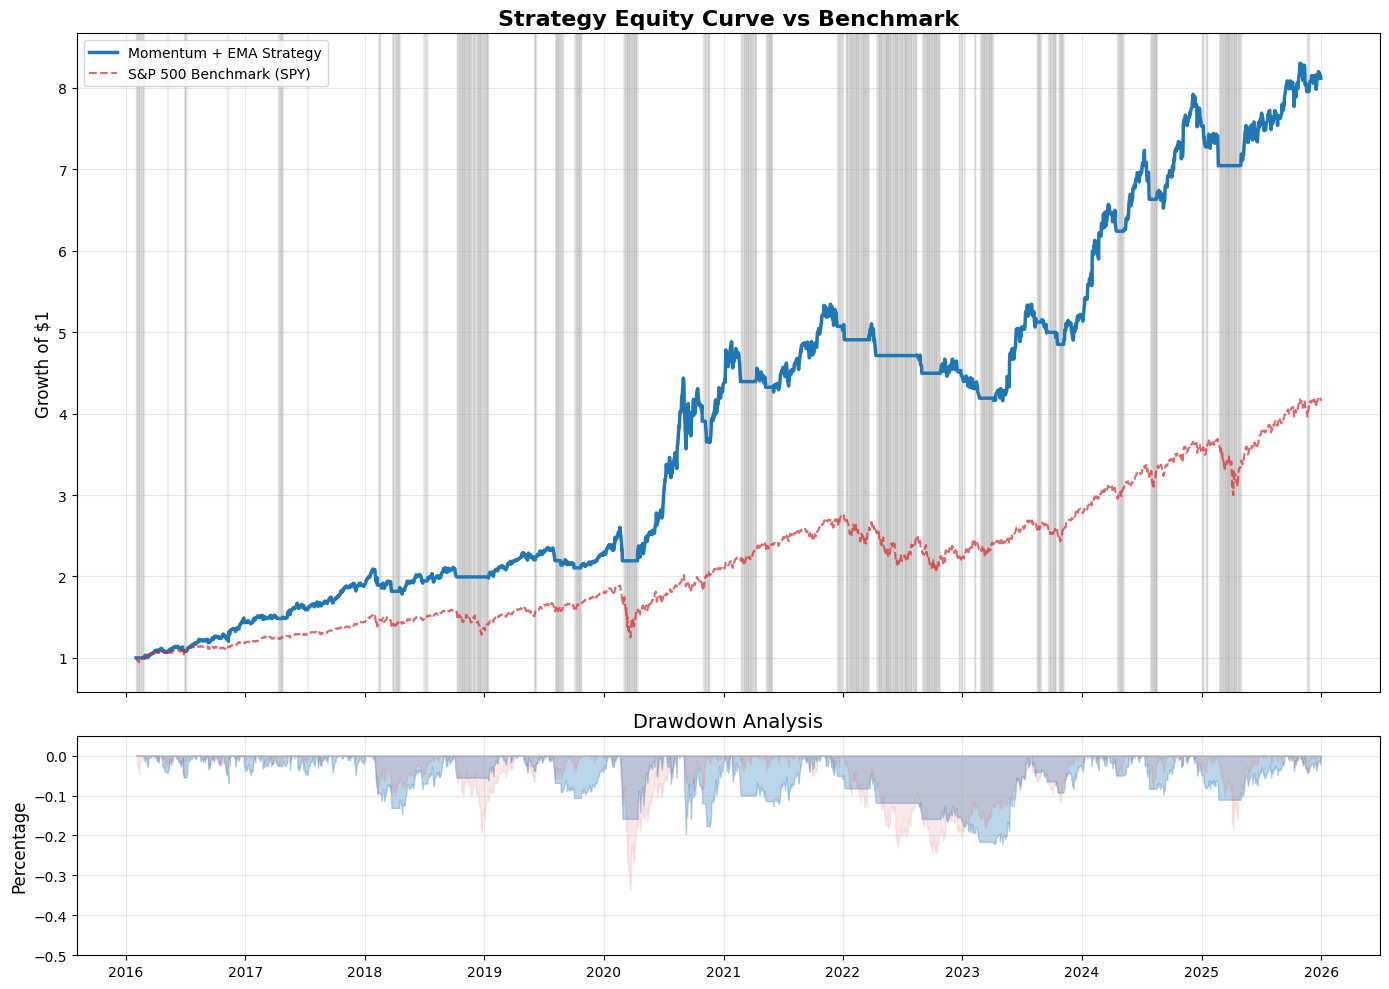

In [ ]:
# Create subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

# Top Plot: Cumulative Returns
ax1.plot((1 + final_strategy_returns).cumprod(), label='Momentum + EMA Strategy', color='#1f77b4', lw=2.5)
ax1.plot((1 + spy_ret_df).cumprod(), label='S&P 500 Benchmark (SPY)', color='#d62728', linestyle='--', alpha=0.7)
ax1.set_title('Strategy Equity Curve vs Benchmark', fontsize=16, fontweight='bold')
ax1.set_ylabel('Growth of $1', fontsize=12)
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Highlight "In-Cash" Periods (where Signal = 0)
cash_periods = signal[signal == 0].index
for period in cash_periods:
    ax1.axvspan(period, period + pd.Timedelta(days=1), color='gray', alpha=0.1)

# Bottom Plot: Drawdowns
ax2.fill_between(strat_metrics[5].index, strat_metrics[5], 0, color='#1f77b4', alpha=0.3, label='Strategy DD')
ax2.fill_between(spy_metrics[5].index, spy_metrics[5].squeeze(), 0, color='#d62728', alpha=0.1, label='SPY DD')
ax2.set_title('Drawdown Analysis', fontsize=14)
ax2.set_ylabel('Percentage', fontsize=12)
ax2.set_ylim(-0.5, 0.05)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

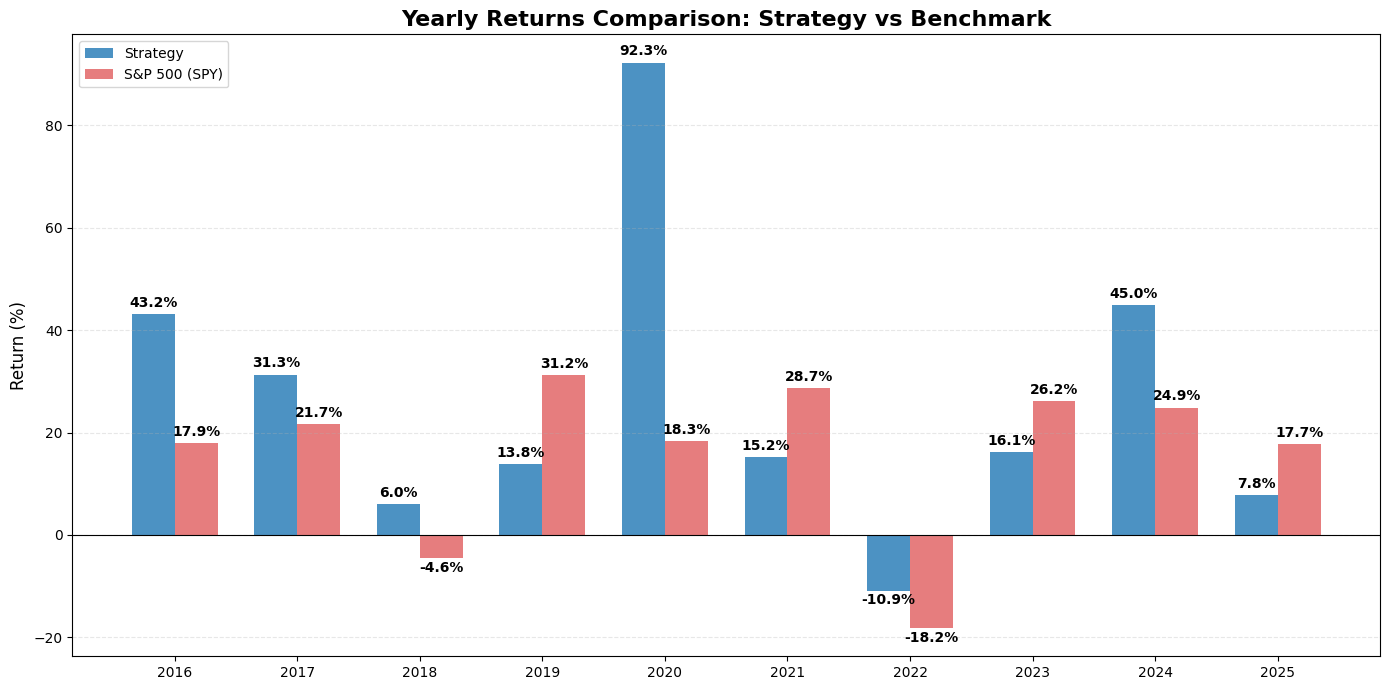

In [ ]:
# 1. Calculate Yearly Returns for Strategy and Benchmark
yearly_strat_ret = (1 + final_strategy_returns).resample('YE').prod() - 1
yearly_spy_ret = (1 + spy_ret_df).resample('YE').prod() - 1

# 2. Prepare data for plotting
years = yearly_strat_ret.index.year
x = np.arange(len(years))  # Label locations
width = 0.35              # Width of the bars

# 3. Create the Plot
plt.figure(figsize=(14, 7))

# Plot bars
rects1 = plt.bar(x - width/2, yearly_strat_ret * 100, width, label='Strategy', color='#1f77b4', alpha=0.8)
rects2 = plt.bar(x + width/2, yearly_spy_ret.values.flatten() * 100, width, label='S&P 500 (SPY)', color='#d62728', alpha=0.6)

# Add text labels on top of bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        plt.annotate(f'{height:.1f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3 if height > 0 else -12),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

# Chart Formatting
plt.axhline(0, color='black', linewidth=0.8) # Baseline at 0
plt.title('Yearly Returns Comparison: Strategy vs Benchmark', fontsize=16, fontweight='bold')
plt.ylabel('Return (%)', fontsize=12)
plt.xticks(x, years)
plt.legend(loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import collections

# 1. Identify the year with the highest return
yearly_returns = (1 + final_strategy_returns).resample('YE').prod() - 1
best_year = yearly_returns.idxmax().year
print(f"--- Best Performing Year: {best_year} ---")

# 2. Track holdings and weights during that year
holdings_log = []
weights_log = collections.defaultdict(list)

for i in range(12, len(monthly_prices) - 1):
    rebalance_date = monthly_prices.index[i]

    # Analyze only the best year
    if rebalance_date.year == best_year:
        # Momentum Selection
        momentum_scores = (monthly_prices.iloc[i] / monthly_prices.iloc[i-12]) - 1
        top10_tickers = momentum_scores[tickers].sort_values(ascending=False).head(10)
        top10_tickers = top10_tickers[top10_tickers > 0]

        if not top10_tickers.empty:
            # Risk-Adjusted Weighting (Momentum / Volatility)
            past_year_returns = daily_returns.loc[:rebalance_date].tail(252)[top10_tickers.index]
            vol = past_year_returns.std() * np.sqrt(252)

            raw_weights = top10_tickers / vol
            final_weights = raw_weights / raw_weights.sum()

            # Record data
            holdings_log.extend(top10_tickers.index.tolist())
            for ticker, weight in final_weights.items():
                weights_log[ticker].append(weight)

# 3. Print the Summary Table
counter = collections.Counter(holdings_log)
print(f"\n{'Ticker':<10} | {'Months Held':<12} | {'Avg. Weight (%)':<15}")
print("-" * 45)

# Sort by frequency of appearance
for ticker, count in counter.most_common():
    avg_weight = np.mean(weights_log[ticker]) * 100
    print(f"{ticker:<10} | {count:<12} | {avg_weight:>14.2f}%")

--- Best Performing Year: 2020 ---

Ticker     | Months Held  | Avg. Weight (%)
---------------------------------------------
TSLA       | 12           |          29.41%
AAPL       | 12           |          12.15%
MSFT       | 12           |           8.59%
NVDA       | 12           |          13.28%
ADBE       | 12           |           6.58%
AMZN       | 10           |           8.98%
PYPL       | 9            |           7.43%
GOOGL      | 8            |           4.33%
META       | 7            |           4.22%
UNH        | 7            |           3.49%
MA         | 4            |           5.74%
HD         | 4            |           4.82%
V          | 3            |           7.19%
PG         | 3            |           5.94%
WMT        | 3            |           7.77%
JPM        | 1            |           7.16%
DIS        | 1            |           2.52%
